<a href="https://colab.research.google.com/github/spentapa3-lgtm/deeplearning-/blob/main/AND_GATE_WITH_TRIANED_WEIGHST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bias is  0.0
Initial Weights + Bias:
Weights: [-0.25091976  0.90142861]
Bias: 0.000

Training Single Perceptron (AND Gate)...
Iteration    0: Loss = 0.4979
Iteration 1000: Loss = 0.3525
Iteration 2000: Loss = 0.2996

Training Complete!
Final Weights: W1=1.315, W2=1.454
Final Bias: -2.272

Predictions (AND Gate):
Input: [0,0] → Pred: 0.093 (0)
Input: [0,1] → Pred: 0.306 (0)
Input: [1,0] → Pred: 0.277 (0)
Input: [1,1] → Pred: 0.622 (1)


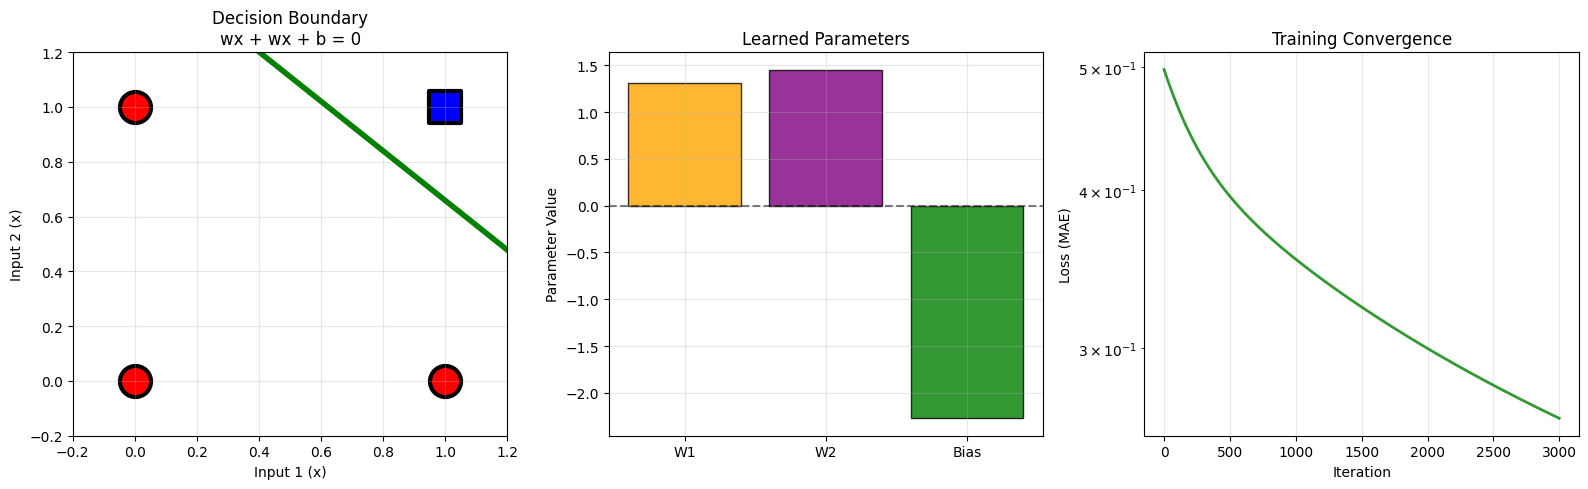


DECISION BOUNDARY VERIFICATION:
Equation: 1.315x1 + 1.454x2 + -2.272 = 0
Solved for x2: x2 = (-1.315x1 - -2.272) / 1.454

Point positions relative to boundary:
[0,0]: -2.272 → Below (Class 0)
[0,1]: -0.818 → Below (Class 0)
[1,0]: -0.957 → Below (Class 0)
[1,1]: 0.497 → Above (Class 1)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
input_size = 2
learning_rate = 0.01
iterations = 3000
print_interval = 1000
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [0], [0], [1]])
np.random.seed(42)
weights = np.random.uniform(-1, 1, (input_size, 1))
bias = np.array([[0.0]])
print("Bias is ",bias[0,0])
print("Initial Weights + Bias:")
print(f"Weights: {weights.flatten()}")
print(f"Bias: {bias[0,0]:.3f}")
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))
def sigmoid_derivative(x):
    return x * (1 - x)
def predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    return sigmoid(linear)
print("\nTraining Single Perceptron (AND Gate)...")
loss_history = []
for iteration in range(iterations):
    linear_output = np.dot(X, weights) + bias
    output = sigmoid(linear_output)
    error = y - output
    d_output = error * sigmoid_derivative(output)
    weights += learning_rate * np.dot(X.T, d_output)
    bias += learning_rate * np.sum(d_output, axis=0, keepdims=True)
    current_loss = np.mean(np.abs(error))
    loss_history.append(current_loss)
    if iteration % print_interval == 0:
        print(f"Iteration {iteration:4d}: Loss = {current_loss:.4f}")
print("\nTraining Complete!")
print(f"Final Weights: W1={weights[0][0]:.3f}, W2={weights[1][0]:.3f}")
print(f"Final Bias: {bias[0][0]:.3f}")
final_predictions = predict(X, weights, bias)
print("\nPredictions (AND Gate):")
for i in range(len(X)):
    pred_class = 1 if final_predictions[i][0] > 0.5 else 0
    print(f"Input: [{X[i][0]:.0f},{X[i][1]:.0f}] → Pred: {final_predictions[i][0]:.3f} ({pred_class})")
plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1], s=500, c='red',
            marker='o', edgecolors='black', linewidth=3, label='Class 0 (AND=0)')
plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1], s=500, c='blue',
            marker='s', edgecolors='black', linewidth=3, label='Class 1 (AND=1)')
w1, w2 = weights[0,0], weights[1,0]
b = bias[0,0]
x1_boundary = np.linspace(-0.2, 1.2, 100)
if abs(w2) > 1e-6:
    x2_boundary = (-w1 * x1_boundary - b) / w2
    plt.plot(x1_boundary, x2_boundary, 'g-', linewidth=4, label='Decision Boundary')
else:
    plt.axvline(x=-b/w1, color='g', linewidth=4, label='Decision Boundary')
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel('Input 1 (x)')
plt.ylabel('Input 2 (x)')
plt.title('Decision Boundary\nwx + wx + b = 0')
plt.grid(True, alpha=0.3)
plt.subplot(1, 3, 2)
params = ['W1', 'W2', 'Bias']
values = [weights[0,0], weights[1,0], bias[0,0]]
plt.bar(params, values, color=['orange', 'purple', 'green'], alpha=0.8,
        edgecolor='black')
plt.ylabel('Parameter Value')
plt.title('Learned Parameters')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.subplot(1, 3, 3)
plt.semilogy(loss_history, 'g-', linewidth=2, alpha=0.8)
plt.xlabel('Iteration')
plt.ylabel('Loss (MAE)')
plt.title('Training Convergence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\nDECISION BOUNDARY VERIFICATION:")
print(f"Equation: {weights[0,0]:.3f}x1 + {weights[1,0]:.3f}x2 + {bias[0,0]:.3f} = 0")
print(f"Solved for x2: x2 = ({-weights[0,0]:.3f}x1 - {bias[0,0]:.3f}) / {weights[1,0]:.3f}")
print("\nPoint positions relative to boundary:")
for i in range(len(X)):
    point_value = weights[0,0]*X[i,0] + weights[1,0]*X[i,1] + bias[0,0]
    side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)"
    print(f"[{X[i,0]:.0f},{X[i,1]:.0f}]: {point_value:.3f} → {side}")